<a href="https://colab.research.google.com/github/Saurabh1222/WalmartSalesForecast/blob/main/WalmartSalesForecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import itertools
from sklearn.metrics import mean_squared_error

In [5]:
data_path = '/content/Walmart DataSet.csv'
data1 = pd.read_csv(
    data_path,
    index_col='Date',
    parse_dates=True,
    dayfirst=True # Assuming dayfirst=True based on your original code
)


In [7]:
data1.info()
print(data1.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6435 entries, 2010-02-05 to 2012-10-26
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 402.2 KB
            Store  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
Date                                                                     
2010-02-05      1    1643690.90             0        42.31       2.572   
2010-02-12      1    1641957.44             1        38.51       2.548   
2010-02-19      1    1611968.17             0        39.93       2.514   
2010-02-26      1    1409727.59             0        46.63       2.

In [9]:
# Store IDs are usually 1-45 based on the original comment
# Filter data for the selected store
store_id = int(input("Enter the store ID (1-45): "))
store_data = data1[data1['Store'] == store_id].copy()

Enter the store ID (1-45): 2


In [10]:
# Aggregate Weekly Sales by Date (which is now the index)
# This step is often necessary if the original data had multiple rows per week/date
# for different departments, and we want total store sales.
sales = store_data['Weekly_Sales'].resample('W').sum() # Resample to weekly ('W') and sum
sales = sales.to_frame(name='Weekly_Sales')
print(f"\n--- Weekly Sales Data for Store {store_id} ---")
print(sales.head())


--- Weekly Sales Data for Store 2 ---
            Weekly_Sales
Date                    
2010-02-07    2136989.46
2010-02-14    2137809.50
2010-02-21    2124451.54
2010-02-28    1865097.27
2010-03-07    1991013.13


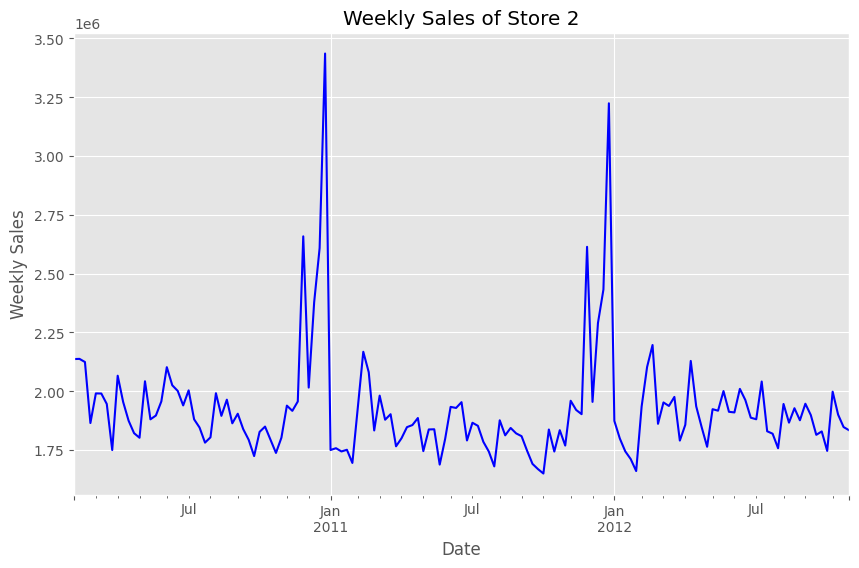

In [11]:
# Plot Weekly Sales
plt.figure(figsize=(10, 6))
sales['Weekly_Sales'].plot(title=f'Weekly Sales of Store {store_id}', color='blue')
plt.ylabel('Weekly Sales')
plt.xlabel('Date')
plt.grid(True)
plt.show()

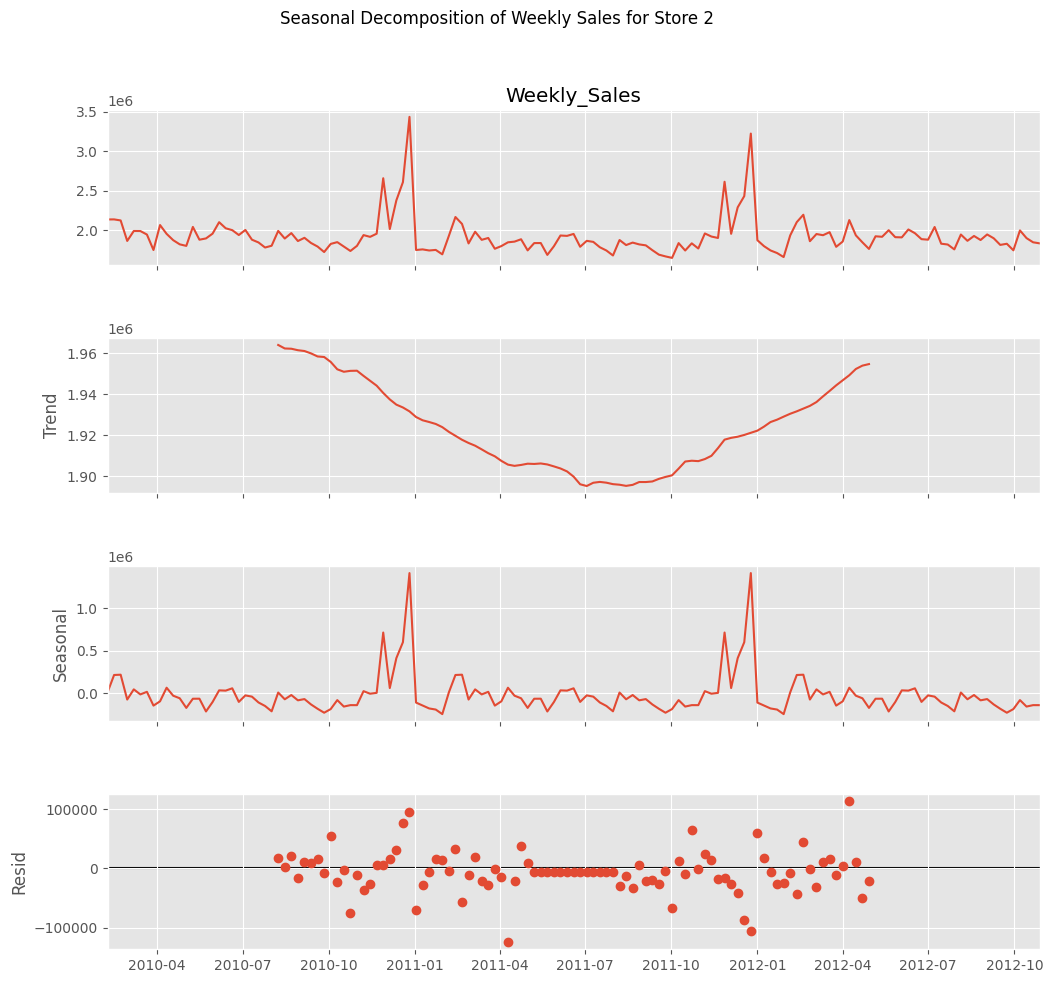

In [12]:
# Perform Seasonal Decomposition
# Set period=52 for yearly seasonality in weekly data (52 weeks in a year)
# Use 'additive' or 'multiplicative' model based on observation (additive is a good default)
decomposition = seasonal_decompose(sales['Weekly_Sales'], model='additive', period=52)

# Plot Decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Seasonal Decomposition of Weekly Sales for Store {store_id}', y=1.02)
plt.show()

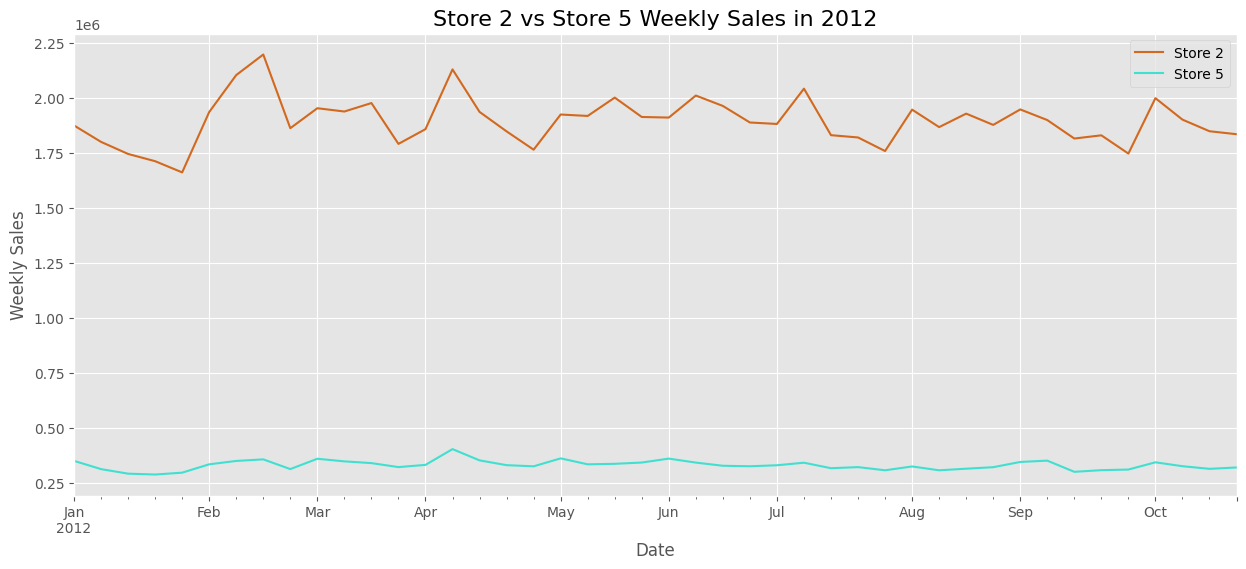

In [13]:
# --- 3. Comparison of Two Stores (Store 5 and the user-selected store) ---

store5_id = 5
# Filter and aggregate sales for Store 5 (or any comparison store)
store5_data = data1[data1['Store'] == store5_id].copy()
sales5 = store5_data['Weekly_Sales'].resample('W').sum().to_frame(name='Weekly_Sales')

# Extract the 'Weekly_Sales' series for modeling/plotting
y1 = sales['Weekly_Sales']
y2 = sales5['Weekly_Sales']

# Plot Comparison for 2012
plt.figure(figsize=(15, 6))
# Use .loc to select the year
y1.loc['2012'].plot(label=f'Store {store_id}', color='chocolate')
y2.loc['2012'].plot(label=f'Store {store5_id}', color='turquoise')
plt.ylabel('Weekly Sales')
plt.xlabel('Date')
plt.title(f'Store {store_id} vs Store {store5_id} Weekly Sales in 2012', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# --- 4. SARIMA Model Tuning (Optional but Recommended) ---
# Your original code used fixed (4, 4, 3)x(1, 1, 0, 52), which might not be optimal.
# This section shows how to find optimal parameters using a grid search (as you started).

# Define the parameter ranges
p = d = q = range(0, 2) # Reduced range for faster testing (0, 2) vs (0, 5)

# Generate all different combinations of p, d, q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, d, q triplets
# We use M=52 for weekly seasonality
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]

print("\n--- SARIMA Parameter Grid Search (RMSE on Training Data) ---")


--- SARIMA Parameter Grid Search (RMSE on Training Data) ---


In [22]:
order_params = (1, 0, 1) # Reduced non-seasonal differencing (d=0)
seasonal_params = (1, 0, 0, 52) # Removed seasonal differencing (D=0)

# --- 5. SARIMA Model Fitting ---

print(f"Fitting SARIMA model with order={order_params} and seasonal_order={seasonal_params}...")

Fitting SARIMA model with order=(1, 0, 1) and seasonal_order=(1, 0, 0, 52)...


In [23]:
# Fit the SARIMAX model
mod = sm.tsa.statespace.SARIMAX(
    y1,
    order=order_params,
    seasonal_order=seasonal_params,
    enforce_stationarity=False, # Often helpful when starting
    enforce_invertibility=False
)

results = mod.fit(disp=False) # disp=False suppresses convergence output

print("\n--- SARIMA Model Summary Table (Coefficients) ---")
print(results.summary().tables[1])


--- SARIMA Model Summary Table (Coefficients) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9755      0.167      5.839      0.000       0.648       1.303
ma.L1         -0.2300      0.360     -0.639      0.523      -0.936       0.476
ar.S.L52       0.8245      0.295      2.794      0.005       0.246       1.403
sigma2      5.814e+10   2.48e-13   2.34e+23      0.000    5.81e+10    5.81e+10


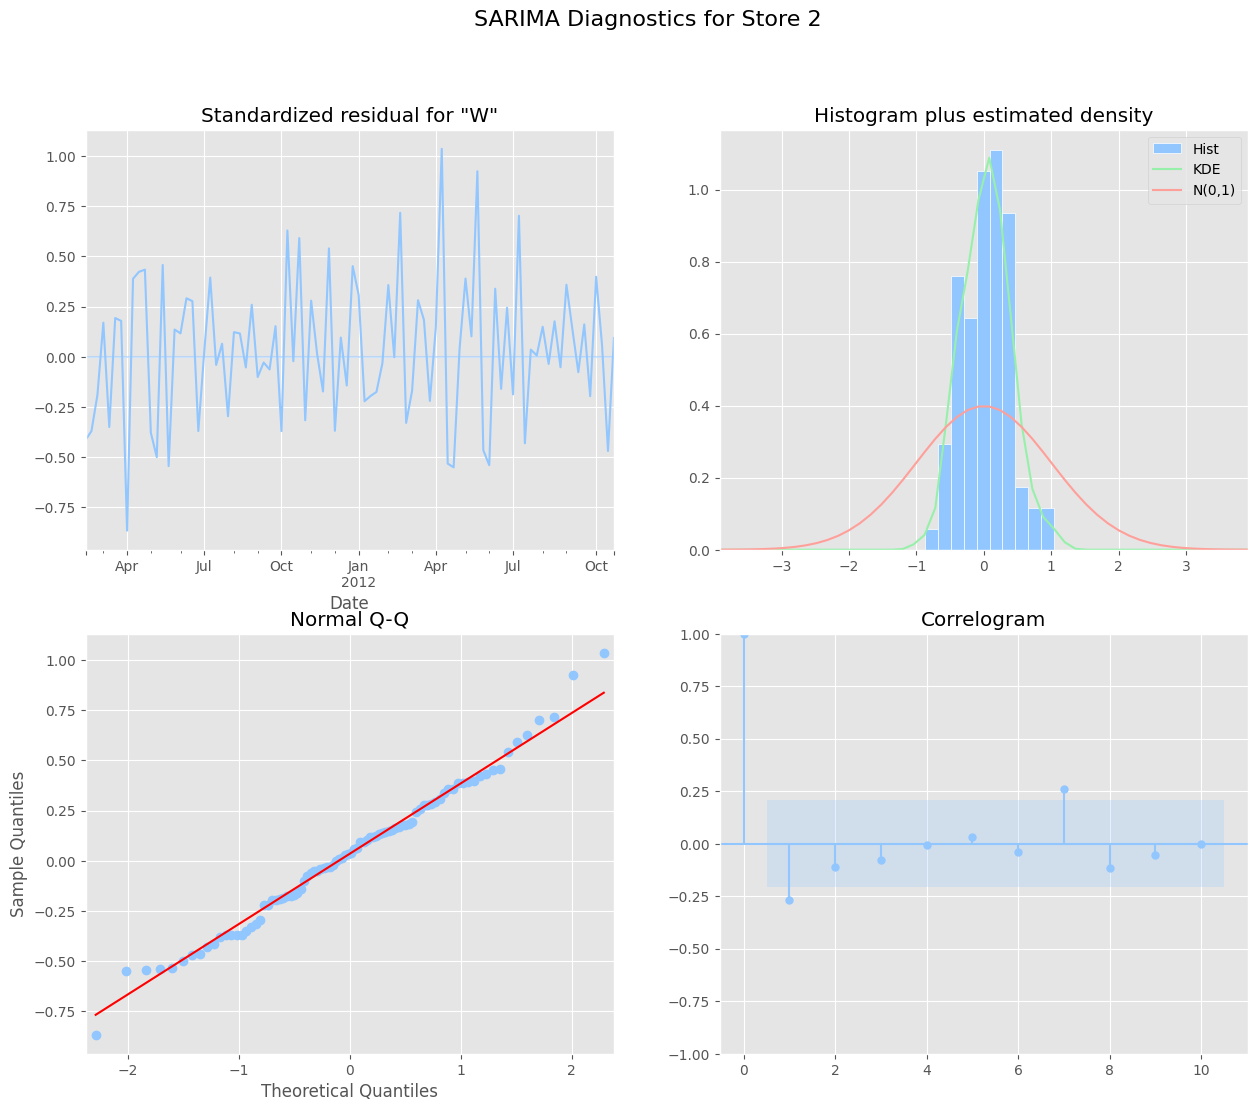

In [25]:
# Plot Diagnostics
results.plot_diagnostics(figsize=(15, 12))
plt.suptitle(f'SARIMA Diagnostics for Store {store_id}', fontsize=16)
plt.show()

In [27]:
# Assuming your time series data is stored in the 'y1' Series
print("Dates in the index near the error:")
print(y1.index[y1.index.year == 2012][-10:]) # Prints the last 10 dates of 2012

Dates in the index near the error:
DatetimeIndex(['2012-08-26', '2012-09-02', '2012-09-09', '2012-09-16',
               '2012-09-23', '2012-09-30', '2012-10-07', '2012-10-14',
               '2012-10-21', '2012-10-28'],
              dtype='datetime64[ns]', name='Date', freq='W-SUN')


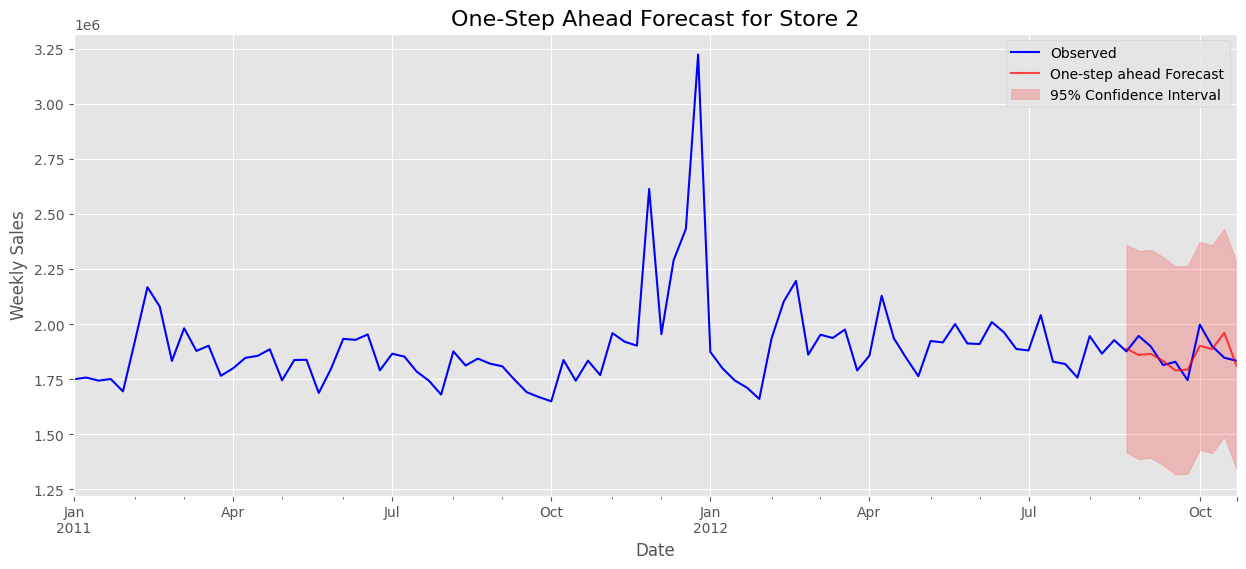

In [28]:
# --- 6. One-Step Ahead Forecast & Evaluation ---

# Define the start date for evaluation (e.g., the last few months of the data)
forecast_start_date = '2012-08-26'

# Get one-step ahead predictions
pred = results.get_prediction(start=pd.to_datetime(forecast_start_date), dynamic=False)
pred_ci = pred.conf_int() # Confidence interval

# Plot the one-step ahead forecast
plt.figure(figsize=(15, 6))
ax = y1.loc['2011':].plot(label='Observed', color='blue') # Start plot from 2011
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=0.7, color='red')

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='red', alpha=0.2, label='95% Confidence Interval')

ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
plt.title(f'One-Step Ahead Forecast for Store {store_id}', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

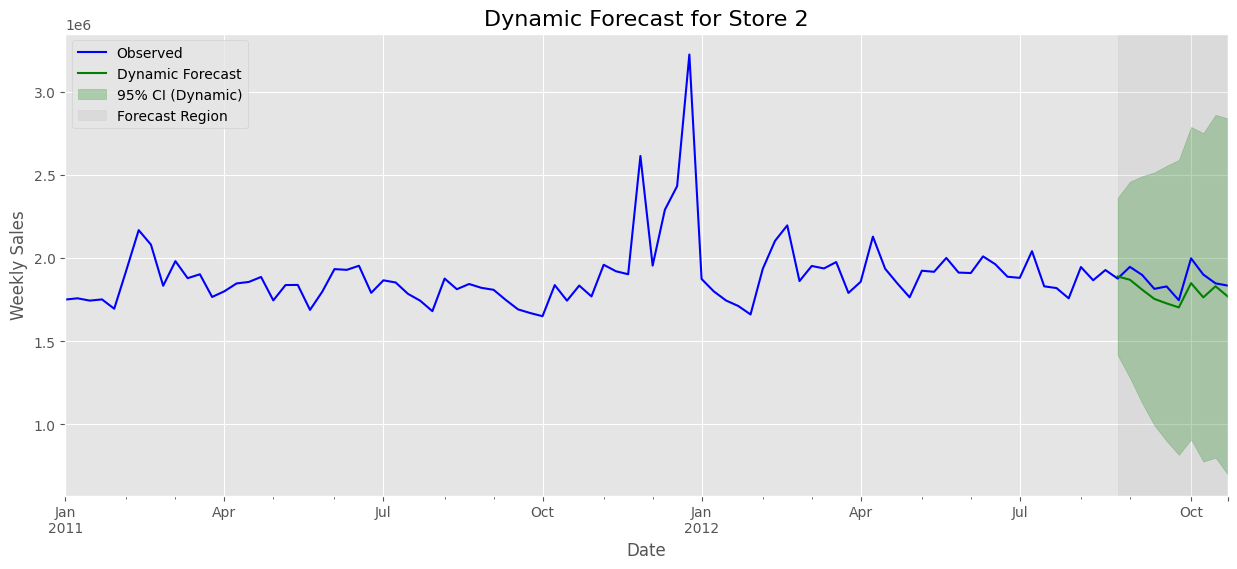


--- Evaluation (Dynamic Forecast from 2012-08-26) ---
The Dynamic Root Mean Squared Error (RMSE) is: 86912.75
Residual (Absolute Sum) for Store 2: 753203.34


In [29]:
# --- 7. Dynamic Forecast & Evaluation ---

# Get dynamic predictions (model uses its own previous predictions)
# full_results=True is not necessary here unless you need the full state space output
pred_dynamic = results.get_prediction(start=pd.to_datetime(forecast_start_date), dynamic=True)
pred_dynamic_ci = pred_dynamic.conf_int()

# Plot the dynamic forecast
plt.figure(figsize=(15, 6))
ax = y1.loc['2011':].plot(label='Observed', color='blue')
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax, color='green')

ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='green', alpha=0.25, label='95% CI (Dynamic)')

# Highlight the forecast region
ax.axvspan(pd.to_datetime(forecast_start_date), y1.index[-1], alpha=0.1, color='gray', label='Forecast Region')

ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
plt.title(f'Dynamic Forecast for Store {store_id}', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Compute RMSE for the dynamic forecast
y_forecasted_dynamic = pred_dynamic.predicted_mean
y_truth_dynamic = y1.loc[forecast_start_date:]

rmse_dynamic = np.sqrt(mean_squared_error(y_truth_dynamic, y_forecasted_dynamic))

print(f'\n--- Evaluation (Dynamic Forecast from {forecast_start_date}) ---')
print(f'The Dynamic Root Mean Squared Error (RMSE) is: {rmse_dynamic:.2f}')
print(f"Residual (Absolute Sum) for Store {store_id}: {np.abs(y_forecasted_dynamic - y_truth_dynamic).sum():.2f}")

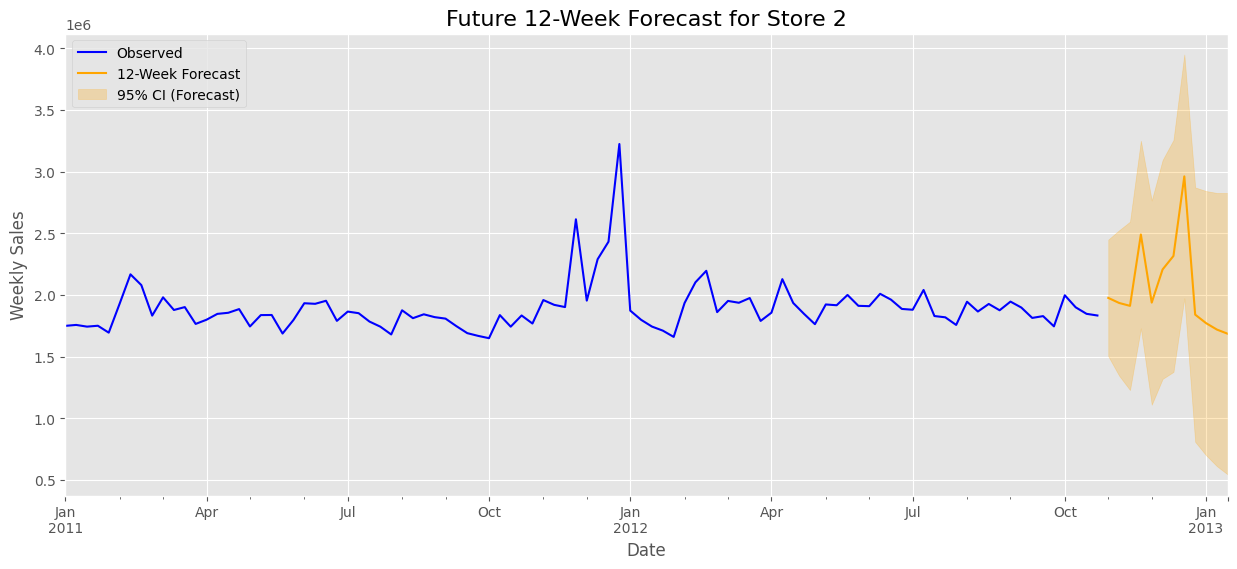

In [30]:
# --- 8. Future Forecast ---

# Get forecast 12 steps (weeks) ahead
forecast_steps = 12
pred_uc = results.get_forecast(steps=forecast_steps)
pred_ci = pred_uc.conf_int()

# Plot the future forecast
plt.figure(figsize=(15, 6))
ax = y1.loc['2011':].plot(label='Observed', color='blue')
pred_uc.predicted_mean.plot(ax=ax, label=f'{forecast_steps}-Week Forecast', color='orange')

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='orange', alpha=0.25, label='95% CI (Forecast)')

ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
plt.title(f'Future {forecast_steps}-Week Forecast for Store {store_id}', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()